# Your first honest backtest

This notebook runs one strategy through the whole pipeline and reads the verdict the way a sceptical reviewer would. Everything executes on the cached data; nothing is downloaded.

**What you will learn:** what a net-of-cost backtest is, why the benchmark comparison matters more than the Sharpe ratio, and what the causality test proves.

In [1]:
import logging, sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.utils.config import load_config
from src.framework import Pipeline, load_default_bundle, load_library
logging.getLogger("src.backtest.engine").setLevel(logging.WARNING)
config = load_config(); load_library()
bundle = load_default_bundle(config)
print(f"{len(bundle.assets)} assets, {bundle.index[0].date()} to {bundle.index[-1].date()}")

15 assets, 2006-01-03 to 2026-09-21


## 1. Run a strategy

Dual momentum holds the four assets with the best 12-month return, but only those that beat cash. A strategy here is a *forecast model* named in a specification; the pipeline does the rest.

In [2]:
spec = {'name': 'dual_momentum', 'models': [{'name': 'dual_momentum'}]}
result = Pipeline(spec, config, bundle).run()
m = result.metrics
print(f"net Sharpe {m['sharpe']:+.2f} (gross {m['gross_sharpe']:+.2f}), CAGR {m['cagr']:.1%}, vol {m['ann_vol']:.1%}, max drawdown {m['max_drawdown']:.1%}, turnover {m['ann_turnover']:.1f}x a year")

net Sharpe +0.86 (gross +0.88), CAGR 9.4%, vol 11.3%, max drawdown -20.1%, turnover 5.1x a year


## 2. Against the dumb alternatives

A positive Sharpe is not the question. The question is whether the strategy beats *holding everything in equal weight*, which needs no forecasts.

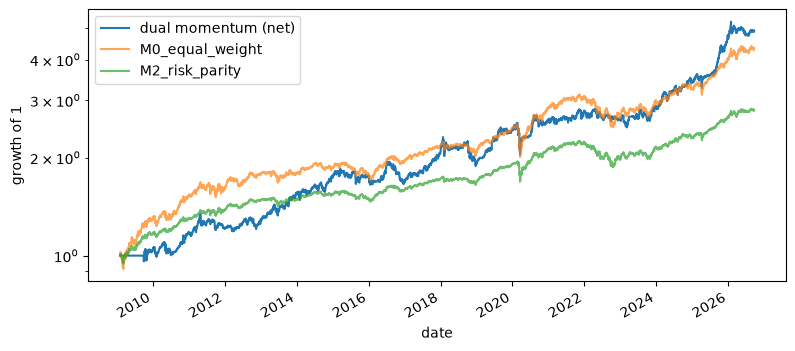

,benchmark,difference,p_value
0,M0_equal_weight,-0.023276,0.9080
1,M2_risk_parity,-0.097214,0.6235


In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
(1 + result.window).cumprod().plot(ax=ax, label='dual momentum (net)')
for name, series in result.benchmarks.items():
    (1 + series.reindex(result.window.index).fillna(0)).cumprod().plot(ax=ax, label=name, alpha=0.7)
ax.set_yscale('log'); ax.set_ylabel('growth of 1'); ax.legend(); plt.show()
result.tables['benchmarks'][['benchmark', 'difference', 'p_value']]

The paired bootstrap resamples both return series on the same dates and asks how often the *difference* in Sharpe ratios would be this large by chance. A large p-value means: no evidence this strategy beats the benchmark.

## 3. The red-flag list

In [4]:
from src.framework.tearsheet import red_flags
pd.DataFrame(red_flags(result))[['rule', 'observed', 'flag']]

,rule,observed,flag
0,Net Sharpe is positive,+0.86,False
1,Positive Sharpe in the final holdout,+1.13,False
2,"Beats M0_equal_weight (paired bootstrap, p <= ...","diff -0.02, p = 0.91",True
3,"Beats M2_risk_parity (paired bootstrap, p <= 0...","diff -0.10, p = 0.62",True
4,Deflated Sharpe probability >= 0.95,1.00 with 1 trial(s) (one trial: the probabili...,False
5,Costs take less than half of the gross Sharpe,gross +0.88 -> net +0.86,False
6,Annual turnover below 10x,5.1x,False
7,Evaluation window of at least 8 years,17.6 years,False
8,Every model and regime detector passes the cau...,all pass,False
9,Forecast beats the climatological Brier score,0.2474 vs 0.2396,True


## 4. What the causality test proves

Each model's forecasts are recomputed after replacing everything beyond a cutoff date with noise. If any forecast on or before the cutoff changes, the model has read the future.

In [5]:
pd.DataFrame(result.validation['causality']).T

,ok,max_abs_difference,availability_mismatches,cutoff,compared
dual_momentum,True,0.0,0,2020-06-30,43080


## 5. Your turn

Change `lookback` to 63 and then to 315 and rerun. Notice how much the Sharpe ratio moves. *That spread is what a researcher who reports only the best parameter hides* (see the technique guide on multiple testing).

In [6]:
rows = []
for lookback in (63, 126, 252, 315):
    r = Pipeline({'name': f'dm{lookback}', 'models': [{'name': 'dual_momentum', 'params': {'lookback': lookback}}], 'evaluation': {'causality': False}}, config, bundle).run(validate=False)
    rows.append({'lookback': lookback, 'net Sharpe': round(r.metrics['sharpe'], 2)})
pd.DataFrame(rows)

,lookback,net Sharpe
0,63,0.47
1,126,0.61
2,252,0.86
3,315,0.61
